# Regional diagnostics

`nispace.diagnostics` holds functions that take an **already-fitted, already-colocalized**
`NiSpace` object as their first argument and compute something derived from it -- they never
re-run `colocalize()`/`permute()` or mutate `nsp`, they just read what's already there. If
`permute()` was also run, several of them pick up its null automatically to give per-region
p-values, with no separate "significance variant" to call.

This notebook covers all three:

- **Regional influence** -- leave-one-region-out sensitivity: how much does removing a region
  change the reported colocalization?
- **Regional contribution** -- an exact additive decomposition of the same colocalization,
  region by region.
- **Local colocalization** -- a "searchlight": recompute colocalization within each region's
  spatial neighborhood, turning one global number into a per-region map.

> **Prerequisite**: this notebook loads pre-computed NiSpace objects saved in
> [intro02](intro02_nispace_intro.ipynb) and [intro10](intro10_xsea.ipynb).
> Run those two notebooks first to generate `intro02_nsp.pkl.blosc` and `intro10_nsp.pkl.blosc`.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from nispace.api import NiSpace
from nispace.plotting import brainplot
import nispace.diagnostics as diagnostics

## Load pre-computed NiSpace objects

We load two NiSpace objects with existing colocalization and permutation results:
- **nsp02**: pain map vs. PET receptor maps (Spearman, Yan200) -- from [intro02](intro02_nispace_intro.ipynb)
- **nsp10**: pain map vs. mRNA cell type markers, XSEA (Spearman, Yan100+TianS1) -- from [intro10](intro10_xsea.ipynb)

In [2]:
nsp02 = NiSpace.from_pickle("intro02_nsp.pkl.blosc")
print("nsp02 -- pain × PET (Yan200):")
print(nsp02.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

print()
nsp10 = NiSpace.from_pickle("intro10_nsp.pkl.blosc")
print("nsp10 -- pain × mRNA XSEA (Yan100+TianS1):")
print(nsp10.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

nsp02 -- pain × PET (Yan200):
INFO | 22/07/26 14:32:54 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
set                          map                                                   
Noradrenaline/Acetylcholine  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017    0.422783
Opioids/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018      0.335397
Noradrenaline/Acetylcholine  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017            0.288889
Histamine                    target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017     0.273213
Glutamate                    target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019      0.180214
Name: Pain, dtype: float32

nsp10 -- pain × mRNA XSEA (Yan100+TianS1):
INFO | 22/07/26 14:32:54 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
M

## Regional influence

*How much does the reported colocalization change when each region is excluded?*

$$\text{influence}_i = \rho_{\text{full}} - \rho_{\text{LOO}(-i)}$$

This is **not** Cook's distance/DFFITS (which flag statistical outliers) -- it directly answers
which brain regions drive the reported effect. `diagnostics.regional_influence()` computes this
either in closed form (`engine="analytic"`, exact and O(n)) for pearson/spearman/partial*/mlr, or
by literally rerunning `colocalize()` once per excluded region (`engine="bruteforce"`) for any
other method except lasso/ridge/elasticnet; `engine="auto"` (default) picks whichever applies.

In [3]:
# Identify the top receptor by |rho| and get its parcellated data
top_pet = nsp02.get_colocalizations().loc["Pain"].abs().idxmax()
print(f"Top receptor: {top_pet}")

x = nsp02.get_x().loc[top_pet]
y = nsp02.get_y().squeeze()

INFO | 22/07/26 14:32:54 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
Top receptor: ('Noradrenaline/Acetylcholine', 'target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017')
INFO | 22/07/26 14:32:54 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 
INFO | 22/07/26 14:32:54 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


In [4]:
# Compute regional influence (uses the analytic engine automatically for spearman)
# Returns a dict keyed by X-map label (receptor), each value (n_Y × n_parcels)
ri02 = diagnostics.regional_influence(nsp02)
infl = ri02[top_pet].squeeze()
print(f"Shape per receptor: {next(iter(ri02.values())).shape}  (n_Y × n_parcels)")

INFO | 22/07/26 14:32:54 | nispace.diagnostics: *** diagnostics.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 115.39it/s]


Shape per receptor: (1, 200)  (n_Y × n_parcels)


In [5]:
print("Regions most inflating the VAChT colocalization (top 5):")
print(infl.sort_values(ascending=False).head(5).to_string())
print("\nRegions most suppressing it (bottom 5):")
print(infl.sort_values().head(5).to_string())

Regions most inflating the VAChT colocalization (top 5):
hemi-L_div-SalVenAttnB_lab-FrMed    0.010450
hemi-R_div-SalVenAttnB_lab-FrMed    0.010024
hemi-R_div-VisualB_lab-Striate+2    0.009921
hemi-R_div-SalVenAttnB_lab-Ins      0.009401
hemi-R_div-SomMotB_lab-Ins          0.009198

Regions most suppressing it (bottom 5):
hemi-R_div-SomMotA_lab-8          -0.019820
hemi-R_div-DorsAttnB_lab-SPL      -0.018040
hemi-L_div-DorsAttnB_lab-SPL      -0.013947
hemi-L_div-SomMotA_lab-8          -0.013549
hemi-L_div-SalVenAttnB_lab-PrCv   -0.013505


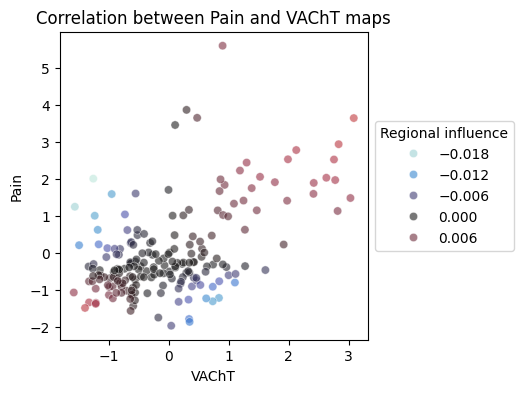

In [6]:
fig, ax = plt.subplots(1, figsize=(4,4))
sn.scatterplot(x=x, y=y, alpha=0.6,
               hue=infl, hue_norm=(-infl.abs().max(), infl.abs().max()), palette="icefire")
ax.set_box_aspect(1)
ax.set_title("Correlation between Pain and VAChT maps")
ax.set_xlabel("VAChT")
ax.legend(loc="center left", bbox_to_anchor=(1,0.5), title="Regional influence")

Regional influence is one value per parcel, so it can also be projected onto the brain -- shown here next to the two input maps.

WARNING | 22/07/26 14:32:58 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/07/26 14:32:58 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 22/07/26 14:32:58 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 22/07/26 14:32:58 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 22/07/26 14:32:58 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06
INFO | 22/07/26 14:32:58 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin6Asym'.
INFO | 22/07/26 14:32:59 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin6Asym'.
INFO | 22/07/26 14:32:59 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin6Asym', surf_mesh='inflated'


(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

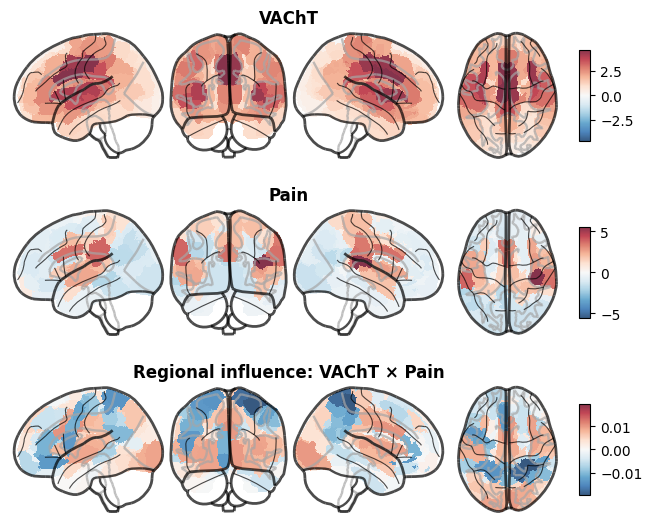

In [7]:
brainplot(
    [x - x.min(), y, infl], # rescale x because 0 is meaningless here
    title=["VAChT", "Pain", "Regional influence: VAChT × Pain"],
    parcellation="Yan200",
)

`regional_influence()` picks up XSEA transparently: if the last `colocalize()` call used `xsea=True`, the result dict is keyed by **set label** (e.g. cell type) instead of individual map label -- no separate function or flag needed.

In [8]:
# nsp10 was colocalized with xsea=True (cell type enrichment) -- picked up automatically
ri10 = diagnostics.regional_influence(nsp10)
print(f"Keys (cell types): {list(ri10.keys())}")

INFO | 22/07/26 14:33:07 | nispace.diagnostics: *** diagnostics.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 1381.52it/s]


Keys (cell types): ['Ex1 CortProject (L2/3)', 'Ex2 Granule (L3/4)', 'Ex3 Granule (L4)', 'Ex4 SubcortProject (L4)', 'Ex5 SubcortProject (L4-6)', 'Ex6 SubcortProject (L5-6)', 'Ex7 Corticothalamic', 'Ex8 Corticothalamic (L6)', 'In1 VIP+RELN+NDNF+ (L1/2)', 'In2 VIP+RELN-NDNF- (L6)', 'In3 VIP+RELN+NDNF- (L6)', 'In4 VIP-RELN+NDNF+ (L1-3)', 'In5 CCK+NOS1+CALB2+ (L2/3)', 'In6 PVALB+CRHBP+ (L4/5)', 'In7 SST+CALB1+NPY+ (L5/6)', 'In8 SST+NOS1+ (L6)', 'Astrocyte', 'Endothelial', 'Developing-quiescent', 'Developing-replicating', 'Microglia', 'Other Neurons', 'OPC', 'Oligodendrocyte']


## Regional contribution

Regional influence asks *how much does removing this region change the correlation?* Regional
contribution asks a simpler, complementary question: *how much does this region add to it?*

$$\text{contribution}_i = z_{X,i} \cdot z_{Y,i}$$

the standardized values at region $i$ (over the same shared NaN mask the correlation itself
uses). This is the **exact additive decomposition** of Pearson's $\rho$ -- the mean over all
regions equals the observed correlation exactly, no leave-one-out refitting needed.

In [9]:
rc02 = diagnostics.regional_contribution(nsp02)
contrib = rc02[top_pet].squeeze()

# verify the additive decomposition: mean(contribution) should equal rho
rho = nsp02.get_colocalizations().loc["Pain", top_pet]
print(f"rho (from colocalize, back-transformed from Z): {np.tanh(rho):.6f}")
print(f"mean(contribution) (decomposed):                {contrib.mean():.6f}")

INFO | 22/07/26 14:33:11 | nispace.diagnostics: *** diagnostics.regional_contribution() - Estimating regional contribution. ***


Regional contribution (spearman, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 346.04it/s]


INFO | 22/07/26 14:33:13 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
rho (from colocalize, back-transformed from Z): 0.399273
mean(contribution) (decomposed):                0.399272


WARNING | 22/07/26 14:33:13 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/07/26 14:33:13 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 22/07/26 14:33:13 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 22/07/26 14:33:13 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 22/07/26 14:33:13 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06
INFO | 22/07/26 14:33:13 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin6Asym'.
INFO | 22/07/26 14:33:14 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin6Asym'.
INFO | 22/07/26 14:33:14 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin6Asym', surf_mesh='inflated'


(<Figure size 720x420 with 12 Axes>, [<Axes: >, <Axes: >])

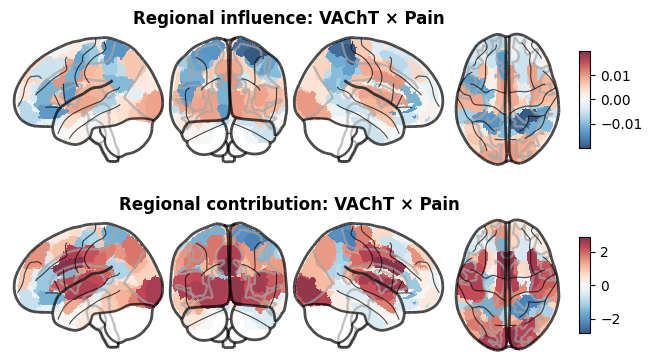

In [10]:
# compare to regional influence from above -- expect broadly similar patterns
brainplot(
    [infl, contrib],
    title=["Regional influence: VAChT × Pain", "Regional contribution: VAChT × Pain"],
    parcellation="Yan200",
)

## Local colocalization

Both diagnostics above still describe a **single, whole-brain** colocalization value. Local
colocalization asks a different question: *does the correlation itself vary across the brain?*
It restricts `colocalize()` to each region's k-nearest spatial neighbors and reruns it there,
turning colocalize()'s usual "one number" into a per-region map -- conceptually a searchlight.

`local_colocalization()` works on **any** `nsp` that has run `colocalize()`, and requires an
explicit `k` (or `radius`) -- there's no sensible default, since the right window size depends
on parcellation resolution and trades off locality against noise (a very small `k` can swing
toward ±1 by chance; too large and it just reconverges to the global value).

If `permute()` was also run, its null is **auto-detected** and reused (re-sliced per window, not
regenerated) to give per-region p-values -- whether that was a spatial `permute(what="maps")` or
a group-comparison `permute(what="groups")` after `transform_y()`. There's no separate
"group" variant of this function: whichever pathway `nsp` already went through is picked up
transparently, the same way `colocalize()` itself already picks up the last `transform_y()`.

In [11]:
# nsp02 already has colocalize() + permute(what="maps") results stored -- both are
# picked up automatically. local_colocalization() always returns a single dict with
# fixed keys (stat_type/mc_method/stat/p/p_corr/settings) -- raw p ("p") is always
# computed alongside the mc_method-corrected p ("p_corr") once a null exists.
k = 30
loc = diagnostics.local_colocalization(nsp02, k=k)
print(f"Settings used: {loc['settings']}")

loc_rho_vacht = loc["stat"][top_pet].squeeze()
loc_p_vacht = loc["p"][top_pet].squeeze()  # raw p values
loc_pc_vacht = loc["p_corr"][top_pet].squeeze()  # step_maxT-corrected p value
print(f"Global rho:                         {np.tanh(rho):.3f}")
print(f"Local rho (k=30) range:             {loc_rho_vacht.min():.3f} to {loc_rho_vacht.max():.3f}")
print(f"Regions with p < .05:               {(loc_p_vacht < .05).sum()} / {len(loc_p_vacht)}")
print(f"Regions with p < .05 (corrected):   {(loc_pc_vacht < .05).sum()} / {len(loc_pc_vacht)}")

INFO | 22/07/26 14:33:21 | nispace.diagnostics: *** diagnostics.local_colocalization() - Computing local colocalization. ***
INFO | 22/07/26 14:33:21 | nispace.nulls: Estimating euclidean distance matrix: fsLR 32k surface parcels, centroid mode.
INFO | 22/07/26 14:33:21 | nispace.nulls: Two-hemispheric parcellation provided, assuming order ['L', 'R'].


Local colocalization null (fast path):  56%|█████▌    | 112/200 [00:02<00:01, 50.63it/s]/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Local colocalization null (fast path): 100%|██████████| 200/200 [00:04<00:00, 46.80it/s]


Settings used: {'k': 30}
Global rho:                         0.399
Local rho (k=30) range:             -0.232 to 0.783
Regions with p < .05:               9 / 200
Regions with p < .05 (corrected):   0 / 200


WARNING | 22/07/26 14:33:27 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/07/26 14:33:27 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 22/07/26 14:33:27 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 22/07/26 14:33:27 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 22/07/26 14:33:27 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06
INFO | 22/07/26 14:33:27 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin6Asym'.
INFO | 22/07/26 14:33:28 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin6Asym'.
INFO | 22/07/26 14:33:28 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin6Asym', surf_mesh='inflated'


(<Figure size 720x1260 with 36 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >])

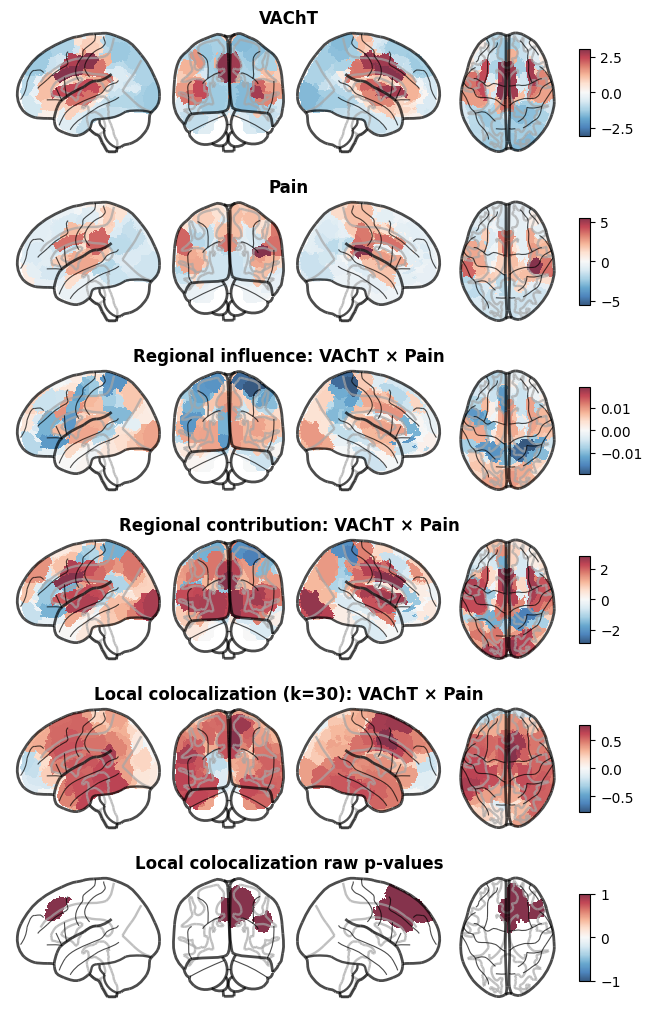

In [12]:
brainplot(
    [x, y, infl, contrib, loc_rho_vacht, loc_p_vacht < 0.05],
    title=[
        "VAChT",
        "Pain",
        "Regional influence: VAChT × Pain",
        "Regional contribution: VAChT × Pain", 
        f"Local colocalization (k={k}): VAChT × Pain",
        "Local colocalization raw p-values"
    ],
    parcellation="Yan200",
)

The same auto-detection applies after a group-comparison workflow -- no code changes needed
beyond what `colocalize()` itself already requires:

```python
# after: nsp.transform_y("hedges(a,b)", groups=...), nsp.colocalize(...), nsp.permute(what="groups")
loc = diagnostics.local_colocalization(nsp, k=30)  # nulls the group contrast automatically
loc["stat"], loc["p"], loc["p_corr"]  # observed, raw p, step_maxT-corrected p
```

## Comparison

The plot below shows how the three methods and the inputs correlate spatially with each other.

Expectedly, the VAChT and Pain maps correlate at 0.4. `regional_influence` and `regional_contribution` correlate very highly with each other. `local_colocalization` shows a different pattern, with equal correlations to both the VAChT and the Pain map of about 0.25.

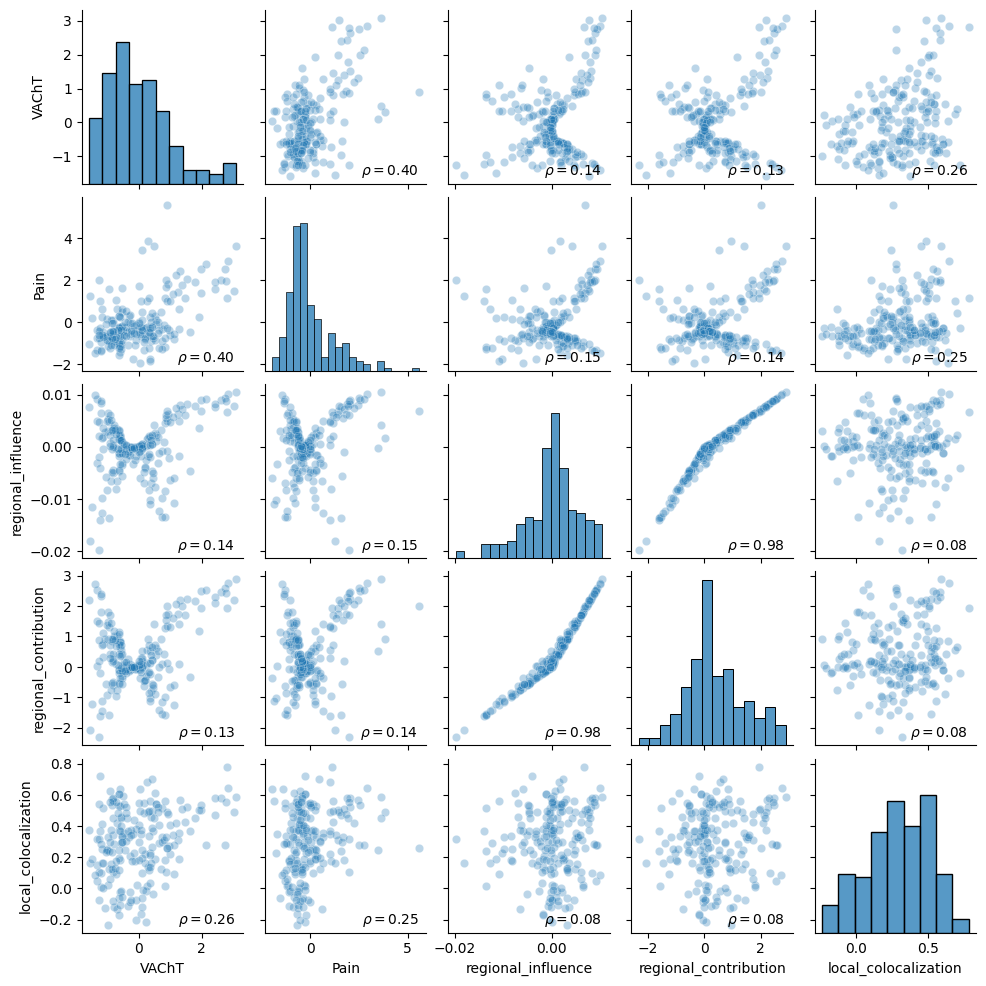

In [13]:
import pandas as pd

comp = pd.DataFrame({
    "VAChT": x,
    "Pain": y,
    "regional_influence": infl,
    "regional_contribution": contrib,
    "local_colocalization": loc_rho_vacht
})

plot = sn.pairplot(comp, height=2, plot_kws={"alpha": 0.3})
for c in range(comp.shape[1]):
    for r in range(comp.shape[1]):
        if r==c: continue
        ax = plot.axes[r,c]
        r = comp.iloc[:,[c,r]].corr(method="spearman").iloc[0,1]
        ax.annotate(rf"$\rho = {r:.02f}$", xycoords="axes fraction", xy=(0.95, 0.05), ha="right")
        

## Summary

- All three functions take a fitted `nsp` as their first argument, read its state, and return
  their result directly -- no `store=`, no getters, nothing persisted on `nsp`.
- `diagnostics.regional_influence(nsp)`: `|stat_full| − |stat_loo|` per region by default
  (`signed=True` for the raw directional delta); `engine="auto"` picks the analytic closed-form
  where available. Picks up XSEA automatically. Not supported for lasso/ridge/elasticnet.
  `pooled="mean"`/`"median"` aggregates across Y maps/subjects.
- `diagnostics.regional_contribution(nsp)`: exact decomposition, `contribution_i = z_X,i · z_Y,i`,
  mean equals rho exactly. `quadrant=True` retrieves `high_high`/`low_low`/`discordant` labels.
- `diagnostics.local_colocalization(nsp, k=...)`: searchlight recomputation of colocalize()
  per region; works for any method except lasso/ridge/elasticnet. Auto-detects and reuses a
  stored `permute()` null (spatial or group) for per-region p-values. Always returns one
  dict: `{"stat_type", "mc_method", "stat", "p", "p_corr", "settings"}` -- raw p (`"p"`) is
  always computed once a null exists, `"p_corr"` (step_maxT-corrected by default) alongside
  it unless `mc_method=None`; `"settings"` reports the `k`/`radius` actually used (plus the
  effective neighbor-count range for `radius`, since window size then varies by region).